In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

In [9]:
# Load the data
df = pd.read_csv('Participant and Task Order 1.csv')  # Skip the second header row

df.columns = [col.replace('\n', ' ') for col in df.columns]

# Conversion process:
# Converte Successful? all Y = 1, N = 0, current score 3 = 1, current score 0-2 = 0 
# (1 represent successful, 0 represent not successful)
df['Successful?'] = df['Successful?'].astype(str)  # Convert all to string
df['Successful?'] = np.where(df['Successful?'] == 'Y', '3',
                           np.where(df['Successful?'] == 'N', '0',
                                   df['Successful?']))
df['Successful?'] = pd.to_numeric(df['Successful?']) 


print(df.iloc[37])
print(df.info())
print(df.describe())

Participant ID             5
Teaching Method            1
Order of Tasks            EH
Round                      3
Target                     B
Completion Time (s)    180.0
Successful?                0
Name: 37, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Participant ID       216 non-null    int64  
 1   Teaching Method      216 non-null    int64  
 2   Order of Tasks       216 non-null    object 
 3   Round                216 non-null    int64  
 4   Target               216 non-null    object 
 5   Completion Time (s)  216 non-null    float64
 6   Successful?          216 non-null    int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 11.9+ KB
None
       Participant ID  Teaching Method       Round  Completion Time (s)  \
count       216.00000       216.000000  216.000000           216.000000   
m

TM1: 31.31 ± 40.64
TM2: 37.75 ± 49.75


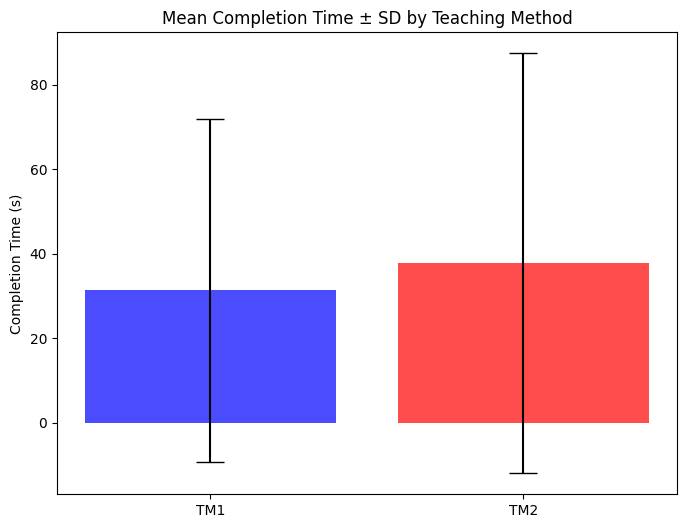

T-test statistic: -1.0421
T-test p-value: 0.2986
No significant difference (p ≥ 0.05)


In [27]:
Completiontime_TM1 = df[df['Teaching Method'] == 1]['Completion Time (s)']
Completiontime_TM2 = df[df['Teaching Method'] == 2]['Completion Time (s)']
tm1_mean, tm1_std = Completiontime_TM1.mean(), Completiontime_TM1.std()
tm2_mean, tm2_std = Completiontime_TM2.mean(), Completiontime_TM2.std()
methods = ['TM1', 'TM2']
means = [tm1_mean, tm2_mean]
stds = [tm1_std, tm2_std]
print(f'TM1: {tm1_mean:.2f} ± {tm1_std:.2f}')
print(f'TM2: {tm2_mean:.2f} ± {tm2_std:.2f}')
plt.figure(figsize=(8, 6))
plt.bar(methods, means, yerr=stds, capsize=10, color=['blue', 'red'], alpha=0.7)
plt.ylabel('Completion Time (s)')
plt.title('Mean Completion Time ± SD by Teaching Method')
plt.show()

t_stat, p_value = ttest_ind(Completiontime_TM1, Completiontime_TM2, equal_var=False)
print(f"T-test statistic: {t_stat:.4f}")
print(f"T-test p-value: {p_value:.4f}")

# Interpret result
if p_value < 0.05:
    print("Significant difference (p < 0.05)")
else:
    print("No significant difference (p ≥ 0.05)")

EH: 37.36 ± 47.43
NH: 31.69 ± 43.38


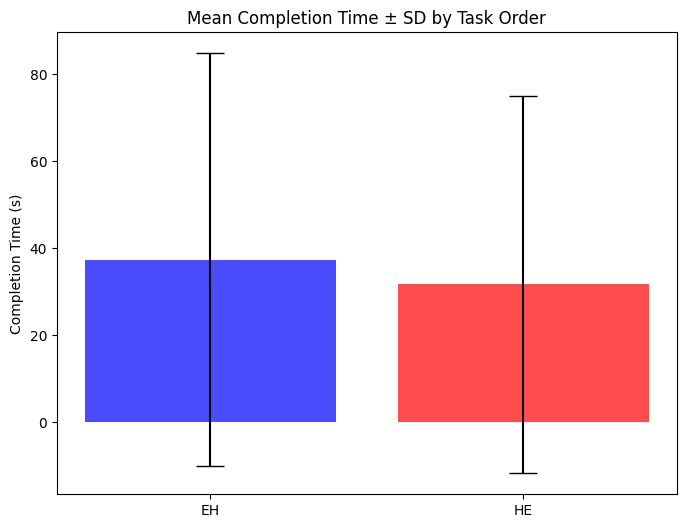

T-test statistic: 0.9164
T-test p-value: 0.3605
No significant difference (p ≥ 0.05)


In [30]:
Completiontime_EH = df[df['Order of Tasks'] == 'EH']['Completion Time (s)']
Completiontime_HE = df[df['Order of Tasks'] == 'HE']['Completion Time (s)']
eh_mean, eh_std = Completiontime_EH.mean(), Completiontime_EH.std()
he_mean, he_std = Completiontime_HE.mean(), Completiontime_HE.std()
methods = ['EH', 'HE']
means = [eh_mean, he_mean]
stds = [eh_std, he_std]
print(f'EH: {eh_mean:.2f} ± {eh_std:.2f}')
print(f'NH: {he_mean:.2f} ± {he_std:.2f}')
plt.figure(figsize=(8, 6))
plt.bar(methods, means, yerr=stds, capsize=10, color=['blue', 'red'], alpha=0.7)
plt.ylabel('Completion Time (s)')
plt.title('Mean Completion Time ± SD by Task Order')
plt.show()

t_stat, p_value = ttest_ind(Completiontime_EH, Completiontime_HE, equal_var=False)
print(f"T-test statistic: {t_stat:.4f}")
print(f"T-test p-value: {p_value:.4f}")
# Interpret result
if p_value < 0.05:
    print("Significant difference (p < 0.05)")
else:
    print("No significant difference (p ≥ 0.05)")

TM1EH: 35.63 ± 44.11
TM1HE: 26.98 ± 36.74
TM2EH: 39.09 ± 50.88
TM2HE: 36.41 ± 49.04


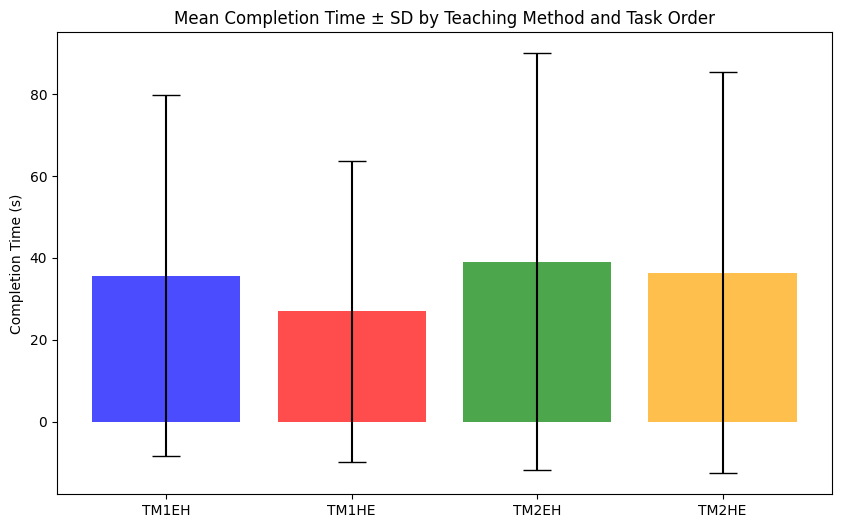

TM1EH vs. TM2EH p-value: 0.7071


In [35]:
Completiontime_TM1EH = df[(df['Teaching Method'] == 1) & (df['Order of Tasks'] == 'EH')]['Completion Time (s)']
Completiontime_TM1HE = df[(df['Teaching Method'] == 1) & (df['Order of Tasks'] == 'HE')]['Completion Time (s)']
Completiontime_TM2EH = df[(df['Teaching Method'] == 2) & (df['Order of Tasks'] == 'EH')]['Completion Time (s)']
Completiontime_TM2HE = df[(df['Teaching Method'] == 2) & (df['Order of Tasks'] == 'HE')]['Completion Time (s)']
tm1eh_mean, tm1eh_std = Completiontime_TM1EH.mean(), Completiontime_TM1EH.std()
tm1he_mean, tm1he_std = Completiontime_TM1HE.mean(), Completiontime_TM1HE.std()
tm2eh_mean, tm2eh_std = Completiontime_TM2EH.mean(), Completiontime_TM2EH.std()
tm2he_mean, tm2he_std = Completiontime_TM2HE.mean(), Completiontime_TM2HE.std()
methods = ['TM1EH', 'TM1HE', 'TM2EH', 'TM2HE'] 
means = [tm1eh_mean, tm1he_mean, tm2eh_mean, tm2he_mean]
stds = [tm1eh_std, tm1he_std, tm2eh_std, tm2he_std]
print(f'TM1EH: {tm1eh_mean:.2f} ± {tm1eh_std:.2f}')
print(f'TM1HE: {tm1he_mean:.2f} ± {tm1he_std:.2f}')
print(f'TM2EH: {tm2eh_mean:.2f} ± {tm2eh_std:.2f}')
print(f'TM2HE: {tm2he_mean:.2f} ± {tm2he_std:.2f}')
plt.figure(figsize=(10, 6))
plt.bar(methods, means, yerr=stds, capsize=10, color=['blue', 'red', 'green', 'orange'], alpha=0.7)
plt.ylabel('Completion Time (s)')
plt.title('Mean Completion Time ± SD by Teaching Method and Task Order')
plt.show()

t_stat, p_value = ttest_ind(Completiontime_TM1EH, Completiontime_TM2EH)
print(f"TM1EH vs. TM2EH p-value: {p_value:.4f}")

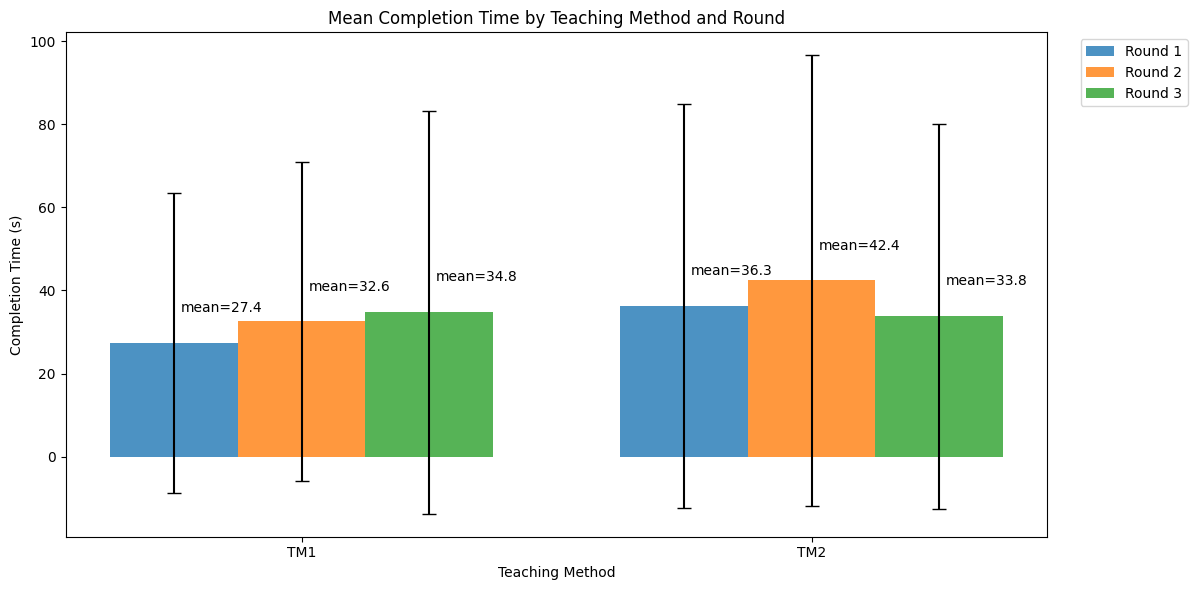


TM1 Results:
            mean        std
Round                      
1      27.388000  36.138080
2      32.568056  38.399831
3      34.780625  48.562846

TM2 Results:
            mean        std
Round                      
1      36.284722  48.718012
2      42.434872  54.221254
3      33.801212  46.309768


In [52]:
grouped = df.groupby(['Teaching Method', 'Round'])['Completion Time (s)'].agg(['mean', 'std']).unstack(level='Round')

# Prepare data for plotting
rounds = sorted(df['Round'].unique())
teaching_methods = sorted(df['Teaching Method'].unique())
x = np.arange(len(teaching_methods))  # x locations for teaching methods
width = 0.25  # width of each round's bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each round within teaching methods
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Distinct colors for rounds
for i, round_num in enumerate(rounds):
    means = grouped[('mean', round_num)]
    stds = grouped[('std', round_num)]
    offset = width * i - (width * (len(rounds)-1)/2)  # Center bars
    bars = ax.bar(x + offset, means, width, 
                 yerr=stds, label=f'Round {round_num}',
                 color=colors[i], capsize=5, alpha=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'mean={height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(5,20),
                   textcoords="offset points",
                   ha='left', va='bottom')

# Customize plot
ax.set_xlabel('Teaching Method')
ax.set_ylabel('Completion Time (s)')
ax.set_title('Mean Completion Time by Teaching Method and Round')
ax.set_xticks(x)
ax.set_xticklabels([f'TM{tm}' for tm in teaching_methods])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

# Print summary statistics organized by Teaching Method
for tm in teaching_methods:
    tm_data = df[df['Teaching Method'] == tm]
    print(f"\nTM{tm} Results:")
    print(tm_data.groupby('Round')['Completion Time (s)'].agg(['mean', 'std']).to_string())

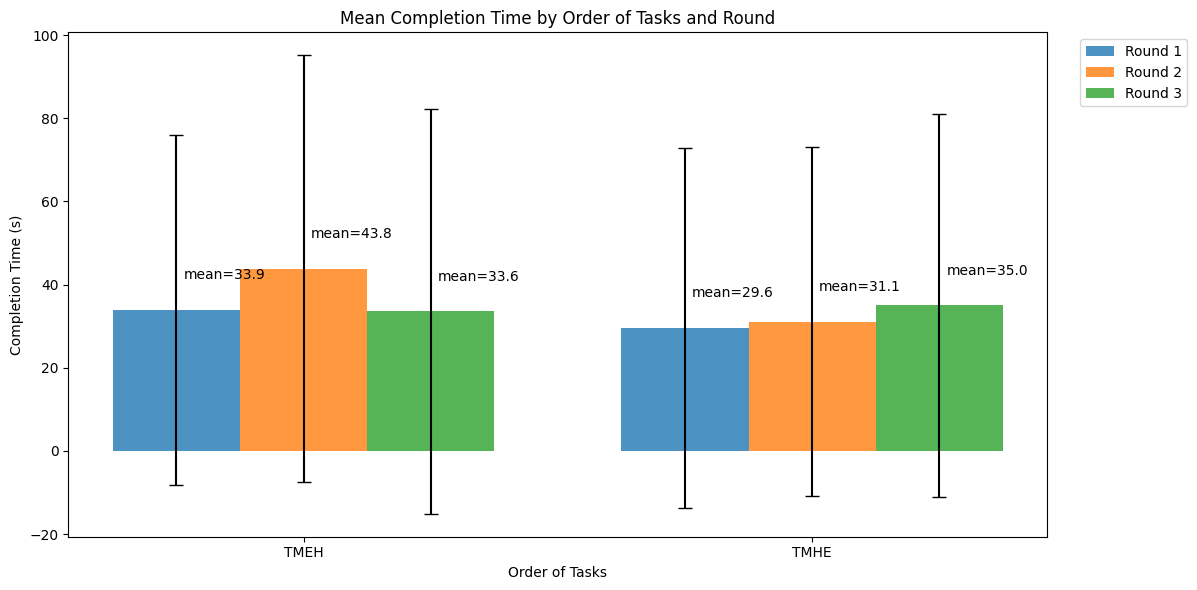


TM1 Results:
Empty DataFrame
Columns: [mean, std]
Index: []

TM2 Results:
Empty DataFrame
Columns: [mean, std]
Index: []


In [53]:
grouped = df.groupby(['Order of Tasks', 'Round'])['Completion Time (s)'].agg(['mean', 'std']).unstack(level='Round')

# Prepare data for plotting
rounds = sorted(df['Round'].unique())
order_of_tasks = sorted(df['Order of Tasks'].unique())
x = np.arange(len(order_of_tasks))  # x locations for order of tasks
width = 0.25  # width of each round's bar

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars for each round within order of tasks
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Distinct colors for rounds
for i, round_num in enumerate(rounds):
    means = grouped[('mean', round_num)]
    stds = grouped[('std', round_num)]
    offset = width * i - (width * (len(rounds)-1)/2)  # Center bars
    bars = ax.bar(x + offset, means, width, 
                 yerr=stds, label=f'Round {round_num}',
                 color=colors[i], capsize=5, alpha=0.8)
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'mean={height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(5,20),
                   textcoords="offset points",
                   ha='left', va='bottom')

# Customize plot
ax.set_xlabel('Order of Tasks')
ax.set_ylabel('Completion Time (s)')
ax.set_title('Mean Completion Time by Order of Tasks and Round')
ax.set_xticks(x)
ax.set_xticklabels([f'TM{tm}' for tm in order_of_tasks])
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()

# Print summary statistics organized by Teaching Method
for tm in teaching_methods:
    tm_data = df[df['Order of Tasks'] == tm]
    print(f"\nTM{tm} Results:")
    print(tm_data.groupby('Round')['Completion Time (s)'].agg(['mean', 'std']).to_string())

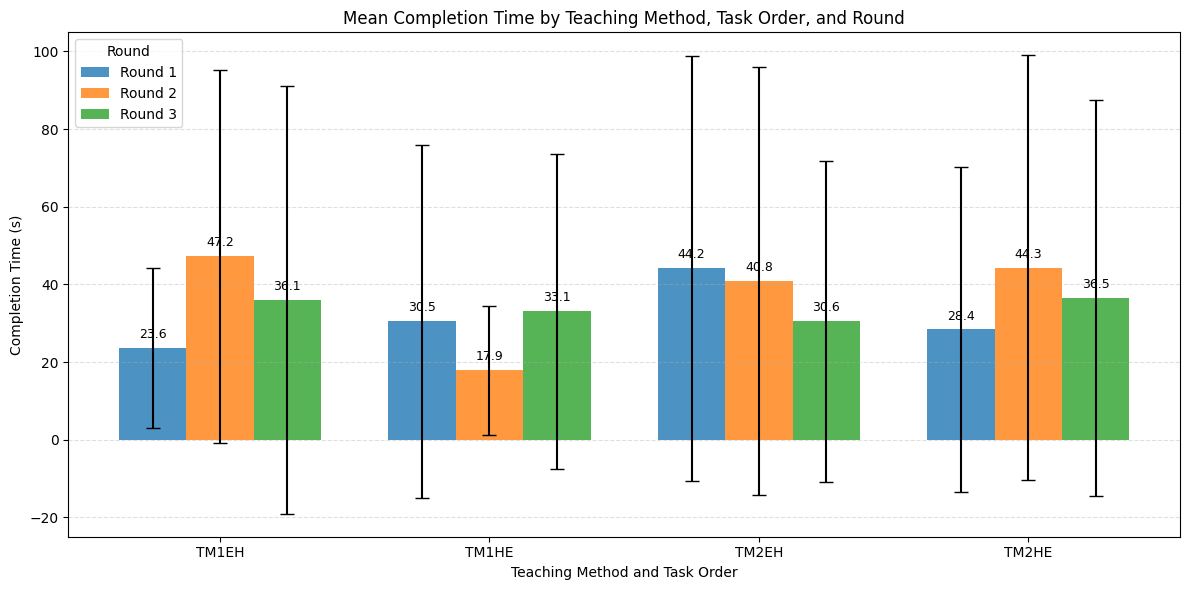

Complete Statistics:
                                     mean                              std  \
Round                                   1          2          3          1   
Teaching Method Order of Tasks                                               
1               EH              23.582222  47.228889  36.090556  20.651467   
                HE              30.501818  17.907222  33.096429  45.360063   
2               EH              44.158333  40.835714  30.550000  54.749376   
                HE              28.411111  44.300556  36.510556  41.925275   

                                                      
Round                                   2          3  
Teaching Method Order of Tasks                        
1               EH              47.995126  55.140694  
                HE              16.647307  40.525223  
2               EH              55.091690  41.353766  
                HE              54.718339  51.102243  


In [60]:
grouped = df.groupby(['Teaching Method', 'Order of Tasks', 'Round'])['Completion Time (s)'] \
            .agg(['mean', 'std']) \
            .unstack(level='Round')

# Create combined labels
grouped['label'] = ['TM'+str(i[0])+i[1] for i in grouped.index]

# Prepare plot data
x_labels = ['TM1EH', 'TM1HE', 'TM2EH', 'TM2HE']
rounds = sorted(df['Round'].unique())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Colors for different rounds

fig, ax = plt.subplots(figsize=(12, 6))
width = 0.25  # Width of each round's bar

# Plot each round's data
for i, round_num in enumerate(rounds):
    means = []
    stds = []
    for label in x_labels:
        # Get the mean and std for this label and round
        tm = int(label[2])  # Extract TM number
        task = label[3:]    # Extract EH/HE
        means.append(grouped.loc[(tm, task), ('mean', round_num)])
        stds.append(grouped.loc[(tm, task), ('std', round_num)])
    
    # Position bars for this round
    offset = width * i - (width * (len(rounds)-1)/2)
    bars = ax.bar(np.arange(len(x_labels)) + offset, means, width,
                 yerr=stds, label=f'Round {round_num}',
                 color=colors[i], capsize=5, alpha=0.8)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 5),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=9)

# Customize plot
ax.set_xlabel('Teaching Method and Task Order')
ax.set_ylabel('Completion Time (s)')
ax.set_title('Mean Completion Time by Teaching Method, Task Order, and Round')
ax.set_xticks(np.arange(len(x_labels)))
ax.set_xticklabels(x_labels)
ax.legend(title='Round')

# Add grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Print the complete data
print("Complete Statistics:")
print(grouped[['mean', 'std']])